# Model Update

## Install & Import Library

In [24]:
# Install Keras Tuner jika belum ada (wajib di Colab)
!pip install -q -U keras-tuner

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import os

Blok ini meng-install dan meng-import seluruh library yang dibutuhkan termasuk keras-tuner.

## Muat & Pre-Processing CIFAR-10

In [25]:
# Cek & buat folder hasil
os.makedirs('result', exist_ok=True)
os.makedirs('metric', exist_ok=True)

# Muat dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalisasi nilai piksel ke [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encoding label
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

Penjelasan:
Dataset di-load, dinormalisasi, dan label diubah ke one-hot vector.

## Data Augmentation

In [26]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)
datagen.fit(x_train)

Penjelasan:
Membuat variasi data gambar selama training untuk mencegah overfitting.

## Model CNN dengan Batch Normalization & Dropout

In [27]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

Penjelasan:
Model CNN dengan batch normalization & dropout agar lebih stabil dan anti-overfitting.

## Alternatif: Transfer Learning (MobileNetV2)

In [28]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32,32,3))
base_model.trainable = False

transfer_model = models.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

/tmp/ipykernel_6334/3963480209.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32,32,3))


Penjelasan:
Jika ingin performa tinggi, gunakan MobileNetV2 sebagai feature extractor (ganti model dengan transfer_model di blok training).

## Hyperparameter Tuning dengan KerasTuner

In [29]:
def build_model(hp):
    model = models.Sequential()
    model.add(layers.Conv2D(
        filters=hp.Choice('conv_1_filter', [32, 64]),
        kernel_size=hp.Choice('conv_1_kernel', [3, 5]),
        padding='same',
        input_shape=(32, 32, 3)
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Conv2D(
        filters=hp.Choice('conv_2_filter', [64, 128]),
        kernel_size=hp.Choice('conv_2_kernel', [3, 5]),
        padding='same'
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(hp.Int('dense_units', 64, 256, step=32), activation='relu'))
    model.add(layers.Dropout(hp.Choice('dropout_rate', [0.3, 0.5])))
    model.add(layers.Dense(10, activation='softmax'))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    directory='kt_tuning',
    project_name='cifar10'
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

# Untuk tuning, jalankan blok ini (bisa lama)
# tuner.search(datagen.flow(x_train, y_train, batch_size=64), epochs=10, validation_data=(x_test, y_test), callbacks=callbacks)
# best_model = tuner.get_best_models(num_models=1)[0]

Penjelasan:
Blok ini untuk mencari kombinasi parameter terbaik. Jika ingin tuning, gunakan model best_model hasil tuning untuk training dan evaluasi.

## Kompilasi & Training Model

In [30]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=50,
    validation_data=(x_test, y_test),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 57ms/step - accuracy: 0.2643 - loss: 1.9509 - val_accuracy: 0.2985 - val_loss: 1.9758 - learning_rate: 0.0010
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 57ms/step - accuracy: 0.3133 - loss: 1.7835 - val_accuracy: 0.2593 - val_loss: 2.0851 - learning_rate: 0.0010
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 57ms/step - accuracy: 0.3403 - loss: 1.7080 - val_accuracy: 0.4584 - val_loss: 1.4513 - learning_rate: 0.0010
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 57ms/step - accuracy: 0.3639 - loss: 1.6633 - val_accuracy: 0.5054 - val_loss: 1.3549 - learning_rate: 0.0010
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 57ms/step - accuracy: 0.3866 - loss: 1.6173 - val_accuracy: 0.5229 - val_loss: 1.2922 - learning_rate: 0.0010
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 57ms/step - accuracy: 0.4054 - loss: 1.5708 - val_accuracy: 0.5694 - val_loss: 1.2256 - learning_rate: 0.0010
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 57ms/step - accuracy: 0.4203 - l

Penjelasan:
Training model utama (atau ganti model dengan transfer_model atau best_model jika mau).

## Visualisasi Hasil Training

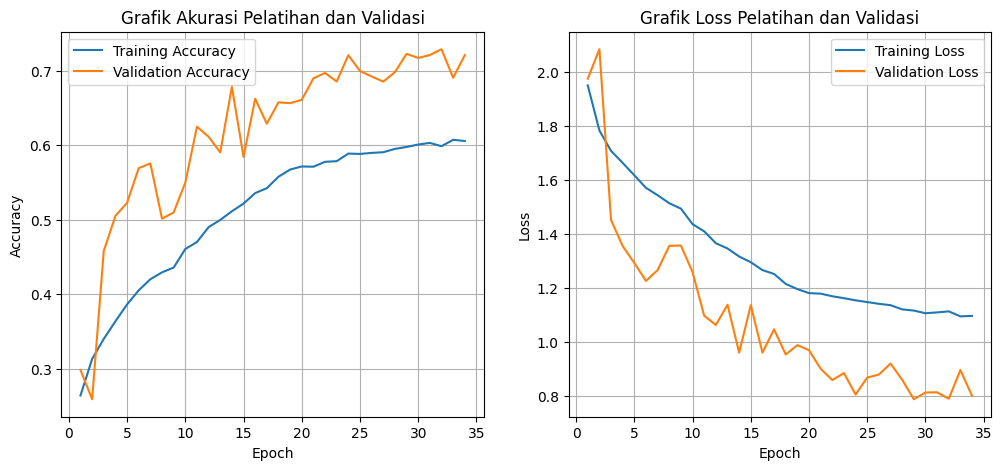

In [35]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

# Plot Akurasi
plt.subplot(1,2,1)
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Grafik Akurasi Pelatihan dan Validasi')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1,2,2)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Grafik Loss Pelatihan dan Validasi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()


Penjelasan:
Visualisasi performa model selama training.

## Evaluasi Model (Akurasi Persentase)

In [36]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Akurasi pada data uji: {test_acc * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7228 - loss: 0.7867
Akurasi pada data uji: 72.28%


Penjelasan:
Mengevaluasi model pada data uji dan menampilkan akurasi.

## Simpan Model & Metrik

In [37]:
model.save('result/cifar10_cnn.keras')

training_metrics = {
    'accuracy': history.history['accuracy'],
    'val_accuracy': history.history['val_accuracy'],
    'loss': history.history['loss'],
    'val_loss': history.history['val_loss']
}
with open('metric/training_metrics.json', 'w') as f:
    json.dump(training_metrics, f)

df_history = pd.DataFrame(history.history)
df_history.to_csv('metric/training_history.csv', index=False)

Penjelasan:
Menyimpan model dan metrik training ke file untuk analisis atau deployment.